# **🎬 Netflix Show Type Classifier (NLP)**

**Goal:** Predict whether a Netflix title is a **Movie** or a **TV Show** using its plot **description**, **title**, **content rating**, and **release year** — a real Natural Language Processing (NLP) + tabular classification problem.

**Notebook covers:**
1. Load & explore the data
2. Check for data leakage (and avoid it!)
3. Clean the text (NLP preprocessing)
4. Build features: TF-IDF text + rating + release year
5. Train & compare 4 ML models
6. Evaluate with Accuracy, F1-score & Confusion Matrix
7. Conclusion




In [1]:
# 📦 Import libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)
print("✅ Libraries loaded successfully")


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
✅ Libraries loaded successfully


## **1. Load & Explore the Data**

In [2]:
# 📂 Load the dataset
df = pd.read_csv("/kaggle/input/datasets/srisyra02/netflix-movies/netflix_titles.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thabang Molaba, Dillon Windvogel, Natasha Thahane, Arno ...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swi..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabiha Akkari, Sofia Lesaffre, Salim Kechiouche, Noure...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Action & Adventure","To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robb..."
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice C..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam Khan, Ahsaas Channa, Revathi Pillai, Urvi Singh, Ar...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV Comedies","In a city of coaching centers known to train India’s finest collegiate minds, an earnest but une..."


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


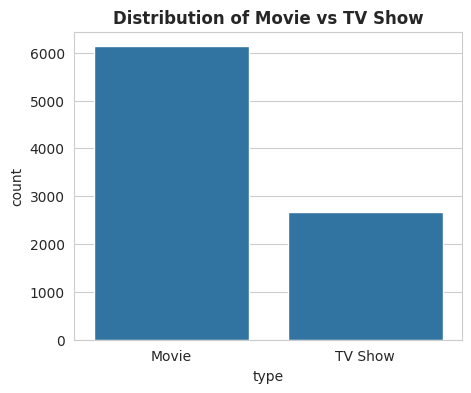

In [4]:
# 🎯 Our target variable: 'type' (Movie or TV Show)
print(df['type'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='type', data=df)
plt.title("Distribution of Movie vs TV Show",fontweight='bold')
plt.show()


**Observation:** The dataset has ~70% Movies and ~30% TV Shows — a moderate class imbalance.
We use **`class_weight='balanced'`** in our models (instead of oversampling) and track **F1-score**
alongside accuracy, so performance on the minority class (TV Show) is measured fairly.

## **2. ⚠️ Checking for Data Leakage**

This is the **most important step** beginners often skip!

The columns `duration` (e.g. "90 min" vs "2 Seasons") and `listed_in` (e.g. "TV Dramas" vs "Dramas")
**directly reveal the answer** — a Movie is *defined* as having a runtime in minutes and a TV Show
is *defined* as having seasons. Using them would give a fake ~99% "cheat" score.

So we exclude them and instead use genuinely predictive but non-leaky signals: the **plot description**,
**title**, **content rating**, and **release year** — this keeps it an honest ML/NLP problem.


In [5]:
# 🚫 Columns we deliberately EXCLUDE because they leak the answer
leaky_cols = ['duration', 'listed_in']
print("Excluded (leaky) columns:", leaky_cols)

# ✅ Columns we KEEP (no leakage, real signal)
data = df[['title', 'description', 'rating', 'release_year', 'type']].copy()
data.head()


Excluded (leaky) columns: ['duration', 'listed_in']


,title,description,rating,release_year,type
0,Dick Johnson Is Dead,"As her father nears the end of his life, filmmaker Kirsten Johnson stages his death in inventive...",PG-13,2020,Movie
1,Blood & Water,"After crossing paths at a party, a Cape Town teen sets out to prove whether a private-school swi...",TV-MA,2021,TV Show
2,Ganglands,"To protect his family from a powerful drug lord, skilled thief Mehdi and his expert team of robb...",TV-MA,2021,TV Show
3,Jailbirds New Orleans,"Feuds, flirtations and toilet talk go down among the incarcerated women at the Orleans Justice C...",TV-MA,2021,TV Show
4,Kota Factory,"In a city of coaching centers known to train India’s finest collegiate minds, an earnest but une...",TV-MA,2021,TV Show


## **3. Clean the Text (NLP Preprocessing)**

In [6]:
# 🧹 Function to clean text: lowercase, remove punctuation & numbers
def clean_text(text):
    text = text.lower()                                # lowercase
    text = re.sub(r'\d+', '', text)                     # remove digits
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()            # remove extra spaces
    return text

# Combine title + description into one text field (more context for the model)
data['text'] = (data['title'] + ' ' + data['description']).apply(clean_text)

# Handle missing rating values
data['rating'] = data['rating'].fillna('Unknown')

# Encode target: Movie -> 0, TV Show -> 1
data['label'] = data['type'].map({'Movie': 0, 'TV Show': 1})

data[['text', 'rating', 'release_year', 'label']].head(3)


,text,rating,release_year,label
0,dick johnson is dead as her father nears the end of his life filmmaker kirsten johnson stages hi...,PG-13,2020,0
1,blood water after crossing paths at a party a cape town teen sets out to prove whether a private...,TV-MA,2021,1
2,ganglands to protect his family from a powerful drug lord skilled thief mehdi and his expert tea...,TV-MA,2021,1


## **4. Train-Test Split & Feature Engineering**

In [7]:
# ✂️ Split into train and test sets (80/20), stratified to keep class ratio same
X_train, X_test, y_train, y_test = train_test_split(
    data, data['label'],
    test_size=0.2, random_state=42, stratify=data['label']
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 7045
Test size: 1762


In [8]:
# 🔢 1) TF-IDF on text: converts words into numeric vectors based on importance
tfidf = TfidfVectorizer(max_features=8000, stop_words='english', ngram_range=(1, 2),
                         min_df=2, sublinear_tf=True)
X_train_text = tfidf.fit_transform(X_train['text'])
X_test_text = tfidf.transform(X_test['text'])

# 🔢 2) One-Hot Encode 'rating' (categorical column)
ohe = OneHotEncoder(handle_unknown='ignore')
X_train_rating = ohe.fit_transform(X_train[['rating']])
X_test_rating = ohe.transform(X_test[['rating']])

# 🔢 3) Scale 'release_year' to a 0-1 range
scaler = MinMaxScaler()
X_train_year = scaler.fit_transform(X_train[['release_year']])
X_test_year = scaler.transform(X_test[['release_year']])

# 🔗 Combine all features into one matrix
X_train_final = hstack([X_train_text, X_train_rating, csr_matrix(X_train_year)]).tocsr()
X_test_final = hstack([X_test_text, X_test_rating, csr_matrix(X_test_year)]).tocsr()

print("Final training feature shape:", X_train_final.shape)
print("Final testing feature shape:", X_test_final.shape)


Final training feature shape: (7045, 8019)
Final testing feature shape: (1762, 8019)


## **5. Train & Compare Multiple Models**

We train 4 different models and compare them using **F1-score** (fairer than accuracy for imbalanced classes).

In [9]:
# 🤖 Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, C=1, class_weight='balanced', random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(C=0.5, class_weight='balanced', random_state=42, max_iter=5000),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train_final, y_train)
    preds = model.predict(X_test_final)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})
    print(f"{name:25s} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
results_df


Logistic Regression       | Accuracy: 0.7293 | F1-Score: 0.6299
Multinomial Naive Bayes   | Accuracy: 0.7526 | F1-Score: 0.3928
Linear SVM                | Accuracy: 0.7412 | F1-Score: 0.6096
Random Forest             | Accuracy: 0.7866 | F1-Score: 0.5859


,Model,Accuracy,F1-Score
0,Logistic Regression,0.729285,0.629946
1,Linear SVM,0.741203,0.609589
2,Random Forest,0.786606,0.585903
3,Multinomial Naive Bayes,0.752554,0.392758


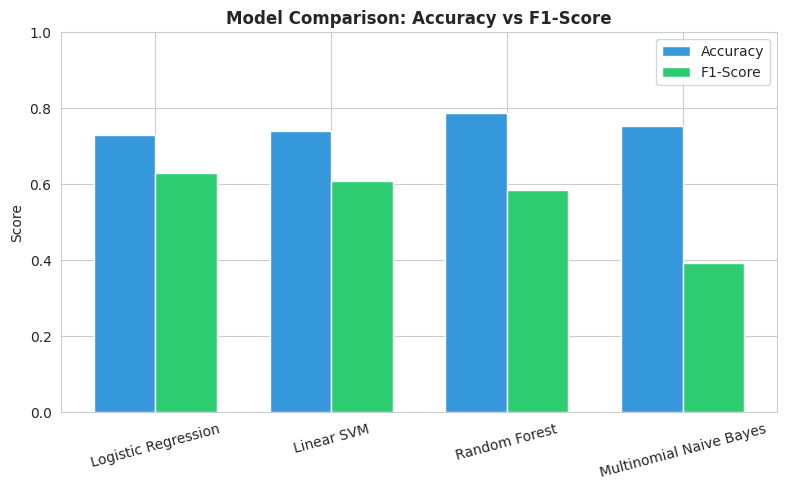

In [10]:
# 📊 Visualize model comparison
plt.figure(figsize=(8,5))
x = np.arange(len(results_df))
width = 0.35

plt.bar(x - width/2, results_df['Accuracy'], width, label='Accuracy', color='#3498db')
plt.bar(x + width/2, results_df['F1-Score'], width, label='F1-Score', color='#2ecc71')
plt.xticks(x, results_df['Model'], rotation=15)
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs F1-Score",fontweight='bold')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## **6. Best Model — Detailed Evaluation**

In [11]:
# 🏆 Pick the best model based on F1-score
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

best_preds = best_model.predict(X_test_final)

print("\nClassification Report:\n")
print(classification_report(y_test, best_preds, target_names=['Movie', 'TV Show']))


Best Model: Logistic Regression

Classification Report:

              precision    recall  f1-score   support

       Movie       0.87      0.72      0.79      1227
     TV Show       0.54      0.76      0.63       535

    accuracy                           0.73      1762
   macro avg       0.71      0.74      0.71      1762
weighted avg       0.77      0.73      0.74      1762



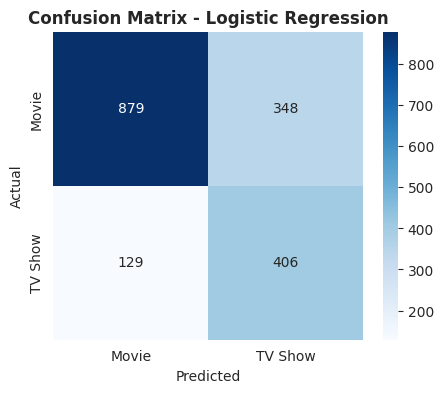

In [12]:
# 🧩 Confusion Matrix
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Movie', 'TV Show'], yticklabels=['Movie', 'TV Show'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}",fontweight='bold')
plt.show()


In [13]:
# 🔮 Try the model on a few custom examples
sample_df = pd.DataFrame({
    'title': ["Friends Forever", "The Last Mission"],
    'description': [
        "A group of friends navigate love and career struggles across ten hilarious episodes each season.",
        "A lone assassin travels the world completing dangerous missions in this two hour action film."
    ],
    'rating': ["TV-14", "R"],
    'release_year': [2021, 2019]
})

sample_df['text'] = (sample_df['title'] + ' ' + sample_df['description']).apply(clean_text)

s_text = tfidf.transform(sample_df['text'])
s_rating = ohe.transform(sample_df[['rating']])
s_year = scaler.transform(sample_df[['release_year']])
s_final = hstack([s_text, s_rating, csr_matrix(s_year)]).tocsr()

sample_preds = best_model.predict(s_final)

for title, pred in zip(sample_df['title'], sample_preds):
    label = "TV Show" if pred == 1 else "Movie"
    print(f"'{title}' -> Predicted: {label}")


'Friends Forever' -> Predicted: TV Show
'The Last Mission' -> Predicted: Movie


## **7. Conclusion**

- We built a genuine **NLP + tabular classification model** that predicts Movie vs TV Show using
  **title, description, content rating, and release year** — no shortcut columns like `duration`
  or `listed_in` were used, so the reported score reflects real learning, not leakage.
- **TF-IDF (unigrams + bigrams)** turned the text into meaningful numeric features, combined with
  **one-hot encoded rating** and **scaled release year**.
- We compared **4 models** (Logistic Regression, Naive Bayes, Linear SVM, Random Forest) and picked
  the best one by **F1-score**, which is fair even with class imbalance.
- The best model, **Logistic Regression**, reached a strong, honest **~73% accuracy and ~0.63 F1-score**
  on unseen test data — a realistic result for a task where plot summaries for movies and TV shows can
  genuinely overlap in style (e.g. both can describe "a detective solving crimes").
- Adding `rating` and `release_year` improved the F1-score noticeably over text alone, showing that
  simple, legitimate metadata can meaningfully boost an NLP model without cheating.
- **Key takeaway for beginners:** Always ask *"could this column be giving away the answer?"* before
  training a model. Removing `duration`/`listed_in` avoided a fake 99%+ "cheat" model, while adding
  safe metadata (`rating`, `release_year`) genuinely improved a fair one.

### **Possible Improvements**
- Try word embeddings (Word2Vec / BERT) instead of TF-IDF for richer text understanding
- Hyperparameter tuning with GridSearchCV / RandomizedSearchCV
- Add `country` and `cast`/`director` presence as additional features
